In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Bollinger Band — Implementation Comparison

Loads standardized signal trades from `results/bollinger_band_trades.csv`
and tests multiple sizing implementations.

**Architecture:** 3 parallel sleeves (SPY/QQQ/IWM), each with 33% capital.
Sizing operates within each sleeve. Sleeves combine at the daily-equity layer.

**Methods:** Simple bet, Fixed Kelly, Asset vol targeting.
**Leverage:** 1x, 2x, 4x, 8x within-sleeve.

## 1. Setup

In [10]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.implementations import (
    simple_bet, asset_vol_targeting,
    build_daily_equity, build_multi_sleeve_equity,
)

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "Bollinger Band"
SAVE_NAME     = "bollinger_band"
INSTRUMENTS   = ["SPY", "QQQ", "IWM"]
SLEEVE_ALLOC  = 1.0 / len(INSTRUMENTS)

pd.set_option("display.max_columns", None)

## 2. Load Signal Trades & Daily Prices

In [11]:
trades_all = pd.read_csv(f"results/{SAVE_NAME}_trades.csv",
                          parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades_all)} trades")
print(f"Period: {trades_all['entry_time'].iloc[0].date()} -> {trades_all['exit_time'].iloc[-1].date()}")
print(f"By instrument: {dict(trades_all['instrument'].value_counts())}")
print(f"Avg hold days: {(trades_all['exit_time'] - trades_all['entry_time']).dt.days.mean():.1f}")

# Split trades by sleeve
sleeve_trades = {
    sym: trades_all[trades_all["instrument"] == sym].reset_index(drop=True)
    for sym in INSTRUMENTS
}

# Fetch daily prices for all 3 instruments
START_DATE = str(trades_all["entry_time"].iloc[0].date())
END_DATE   = str(trades_all["exit_time"].iloc[-1].date())

daily_data = fetch_historical_data(
    INSTRUMENTS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

daily_prices = {}
daily_for_avt = {}
for sym in INSTRUMENTS:
    d = daily_data[sym].reset_index()
    d["date"] = pd.to_datetime(d["timestamp"]).dt.tz_localize(None).dt.normalize()
    daily_prices[sym]  = d.set_index("date")["close"]
    daily_for_avt[sym] = d[["date", "close"]].set_index("date")
    print(f"{sym}: {len(daily_prices[sym])} daily bars")

Loaded 57 trades
Period: 2016-05-02 -> 2026-03-31
By instrument: {'IWM': 21, 'QQQ': 18, 'SPY': 18}
Avg hold days: 83.8
Fetching SPY...
  2,492 bars
Fetching QQQ...
  2,492 bars
Fetching IWM...
  2,492 bars
SPY: 2492 daily bars
QQQ: 2492 daily bars
IWM: 2492 daily bars


## 3. Per-Sleeve Engine

Runs sizing per-sleeve, injects actual share counts (from sizing function),
builds daily equity with mark-to-market, combines sleeves into portfolio.

In [12]:
def _add_shares(trades, shares_per_trade):
    """Inject actual share counts from sizing function into trades DataFrame."""
    t = trades.copy()
    t["shares"] = shares_per_trade
    return t


def _portfolio_stats(combined):
    daily_returns = combined.pct_change().dropna()
    total_return = (combined.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ann_sharpe = (daily_returns.mean() / daily_returns.std() * np.sqrt(252)
                   if daily_returns.std() > 0 else 0)
    peak = combined.expanding().max()
    max_dd = ((combined - peak) / peak).min() * 100
    years = (combined.index[-1] - combined.index[0]).days / 365.25
    cagr = ((combined.iloc[-1] / STARTING_CAPITAL) ** (1 / years) - 1) * 100 if years > 0 else 0
    return {
        "total_return": round(total_return, 1),
        "cagr":         round(cagr, 2),
        "sharpe":       round(ann_sharpe, 2),
        "max_dd":       round(max_dd, 1),
    }


def run_per_sleeve(sizing_fn, label, **kwargs):
    """Run sizing function per-sleeve, combine into portfolio."""
    sleeve_capital = STARTING_CAPITAL * SLEEVE_ALLOC
    sleeve_daily = {}

    for sym in INSTRUMENTS:
        t = sleeve_trades[sym]
        if t.empty:
            sleeve_daily[sym] = pd.Series(sleeve_capital, index=daily_prices[sym].index)
            continue
        res = sizing_fn(t, starting_capital=sleeve_capital, **kwargs)
        # Use ACTUAL shares from sizing function — no approximation
        t_with_shares = _add_shares(t, res["shares_per_trade"])
        sleeve_daily[sym] = build_daily_equity(
            t_with_shares, res["equity_curve"], sleeve_capital,
            daily_prices=daily_prices[sym])

    combined = build_multi_sleeve_equity(sleeve_daily, STARTING_CAPITAL)
    return {"label": label, "daily_equity": combined,
            "sleeve_daily": sleeve_daily, "stats": _portfolio_stats(combined)}


def run_asset_vol_per_sleeve(target_vol, lookback, max_leverage, label):
    """asset_vol_targeting with per-sleeve prices."""
    sleeve_capital = STARTING_CAPITAL * SLEEVE_ALLOC
    sleeve_daily = {}

    for sym in INSTRUMENTS:
        t = sleeve_trades[sym]
        if t.empty:
            sleeve_daily[sym] = pd.Series(sleeve_capital, index=daily_prices[sym].index)
            continue
        res = asset_vol_targeting(t, daily_for_avt[sym],
                                    target_vol=target_vol, lookback=lookback,
                                    max_leverage=max_leverage,
                                    starting_capital=sleeve_capital)
        t_with_shares = _add_shares(t, res["shares_per_trade"])
        sleeve_daily[sym] = build_daily_equity(
            t_with_shares, res["equity_curve"], sleeve_capital,
            daily_prices=daily_prices[sym])

    combined = build_multi_sleeve_equity(sleeve_daily, STARTING_CAPITAL)
    return {"label": label, "daily_equity": combined,
            "sleeve_daily": sleeve_daily, "stats": _portfolio_stats(combined)}


def print_portfolio_comparison(results):
    print(f"{'Label':<45} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
    print("-" * 85)
    for r in results:
        s = r["stats"]
        print(f"{r['label']:<45} {s['total_return']:>10,.1f} {s['cagr']:>8.2f} "
              f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

## 4. Base Sizing Comparison (1x)

- **Simple bet** — fixed fraction of sleeve equity
- **Fixed Kelly** — Kelly f* from full trade history. Quarter Kelly = 1x baseline.
- **Asset vol targeting** — sizes by underlying realized vol

Kelly sweep: Quarter=1x, Half=2x, Full=4x, Double=8x.

In [13]:
# ── Compute Kelly f* from ALL trades combined ──
rets_all = trades_all["pct_return_gross"].values
wins_all = rets_all[rets_all > 0]
losses_all = rets_all[rets_all < 0]
if len(wins_all) >= 3 and len(losses_all) >= 1:
    p = len(wins_all) / len(rets_all)
    b = wins_all.mean() / abs(losses_all.mean())
    KELLY_F = max((p * b - (1 - p)) / b, 0.01)
else:
    KELLY_F = 0.10

print(f"Kelly f* from {len(trades_all)} trades:")
print(f"  Win rate: {p*100:.1f}%, W/L ratio: {b:.2f}")
print(f"  Full Kelly f*: {KELLY_F:.2%}")
print(f"  Quarter={KELLY_F*0.25:.1%}, Half={KELLY_F*0.5:.1%}, "
      f"Full={KELLY_F:.1%}, Double={KELLY_F*2:.1%}\n")

def _simple_sleeve(trades, starting_capital, bet_size):
    return simple_bet(trades, bet_size=bet_size, starting_capital=starting_capital)

def _kelly_sleeve(trades, starting_capital, kelly_mult):
    return simple_bet(trades, bet_size=KELLY_F * kelly_mult,
                       starting_capital=starting_capital)


Kelly f* from 57 trades:
  Win rate: 75.4%, W/L ratio: 2.46
  Full Kelly f*: 65.47%
  Quarter=16.4%, Half=32.7%, Full=65.5%, Double=130.9%



In [14]:
r_simple = run_per_sleeve(_simple_sleeve, label="Simple bet 85% (1x)", bet_size=0.85)
r_kelly  = run_per_sleeve(_kelly_sleeve,  label=f"Quarter Kelly {KELLY_F*0.25:.0%} (1x)", kelly_mult=0.25)
r_avt    = run_asset_vol_per_sleeve(target_vol=0.10, lookback=60, max_leverage=1.0,
                                      label="Asset vol 10%, 1x")

base_results = [r_simple, r_kelly, r_avt]
print("BASE COMPARISON (1x within-sleeve):\n")
print_portfolio_comparison(base_results)


BASE COMPARISON (1x within-sleeve):

Label                                            TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Simple bet 85% (1x)                                136.8     9.09     0.73    -23.7
Quarter Kelly 16% (1x)                              18.5     1.73     0.74     -4.6
Asset vol 10%, 1x                                  173.7    10.69     0.73    -27.9


## 5. Leverage Sweep

All 3 methods at 2x, 4x, 8x within-sleeve.
Kelly maps: Quarter=1x, Half=2x, Full=4x, Double=8x.

Note: Full Kelly is the theoretical max long-term CAGR.
Double Kelly exceeds optimal — included to show the over-betting penalty.

In [15]:
KELLY_MAP = {1: 0.25, 2: 0.5, 4: 1.0, 8: 2.0}
KELLY_NAMES = {1: "Quarter", 2: "Half", 4: "Full", 8: "Double"}

LEVERAGE_LEVELS = [2, 4, 8]
sweep_results = {}

for lev in LEVERAGE_LEVELS:
    sweep_results[lev] = [
        run_per_sleeve(_simple_sleeve,
                         label=f"Simple bet {int(85*lev)}% ({lev}x)",
                         bet_size=0.85 * lev),
        run_per_sleeve(_kelly_sleeve,
                         label=f"{KELLY_NAMES[lev]} Kelly {KELLY_F*KELLY_MAP[lev]:.0%} ({lev}x)",
                         kelly_mult=KELLY_MAP[lev]),
        run_asset_vol_per_sleeve(target_vol=0.10, lookback=60,
                                    max_leverage=float(lev),
                                    label=f"Asset vol 10%, {lev}x"),
    ]

print("ALL METHODS AT 4x:\n")
print_portfolio_comparison(sweep_results[4])

print("\n\nSIMPLE BET -- SWEEP:")
print_portfolio_comparison([base_results[0]] + [sr[0] for sr in sweep_results.values()])

print("\nKELLY -- SWEEP (Quarter->Half->Full->Double):")
print_portfolio_comparison([base_results[1]] + [sr[1] for sr in sweep_results.values()])

print("\nASSET VOL -- SWEEP:")
print_portfolio_comparison([base_results[2]] + [sr[2] for sr in sweep_results.values()])


ALL METHODS AT 4x:

Label                                            TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Simple bet 340% (4x)                             2,055.6    36.32     0.70    -89.6
Full Kelly 65% (4x)                                 95.6     7.00     0.73    -18.4
Asset vol 10%, 4x                                2,565.1    39.27     0.07   -108.6


SIMPLE BET -- SWEEP:
Label                                            TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Simple bet 85% (1x)                                136.8     9.09     0.73    -23.7
Simple bet 170% (2x)                               423.2    18.17     0.72    -46.7
Simple bet 340% (4x)                             2,055.6    36.32     0.70    -89.6
Simple bet 680% (8x)                            23,332.8    73.42    -0.33   -160.9

KELLY -- SWEEP (Quarter->Hal

## 6. Equity Curves

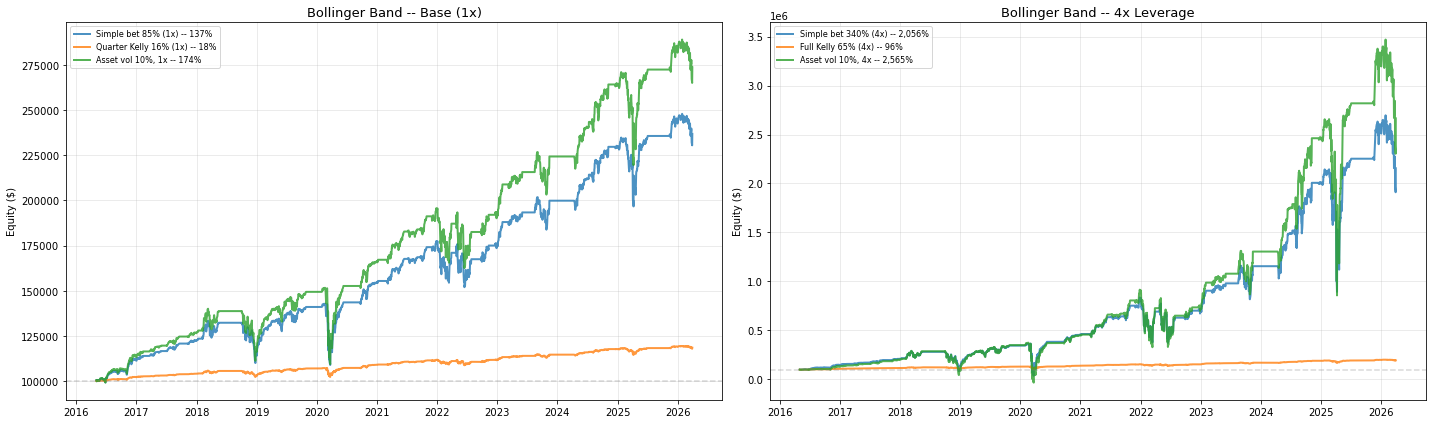

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

ax = axes[0]
for r in base_results:
    eq = r["daily_equity"]
    ret = (eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{r['label']} -- {ret:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- Base (1x)", fontsize=13)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")

ax = axes[1]
for r in sweep_results[4]:
    eq = r["daily_equity"]
    ret = (eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{r['label']} -- {ret:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- 4x Leverage", fontsize=13)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")

plt.tight_layout(); plt.show()

## 7. Per-Sleeve Decomposition

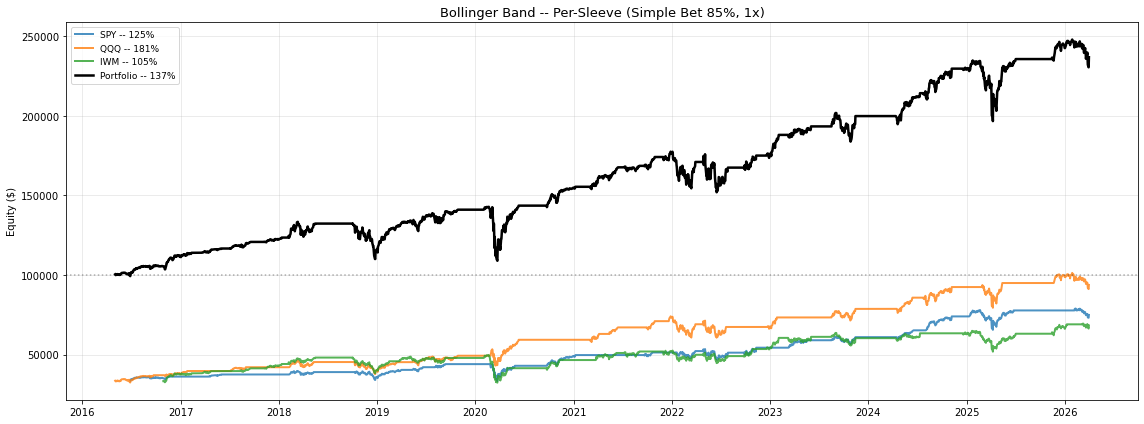


Sleeve       Trades        End $   Return %
---------------------------------------------
SPY              18       74,862      124.6
QQQ              18       93,720      181.2
IWM              21       68,253      104.8


In [17]:
fig, ax = plt.subplots(figsize=(16, 6))
sleeve_capital = STARTING_CAPITAL * SLEEVE_ALLOC
for sym in INSTRUMENTS:
    eq = r_simple["sleeve_daily"][sym]
    ret = (eq.iloc[-1] / sleeve_capital - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{sym} -- {ret:,.0f}%")
eq = r_simple["daily_equity"]
ax.plot(eq.index.to_numpy(), eq.values, linewidth=2.5, color="black",
          label=f"Portfolio -- {(eq.iloc[-1]/STARTING_CAPITAL-1)*100:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- Per-Sleeve (Simple Bet 85%, 1x)", fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"\n{'Sleeve':<10} {'Trades':>8} {'End $':>12} {'Return %':>10}")
print("-" * 45)
for sym in INSTRUMENTS:
    n = len(sleeve_trades[sym])
    end = r_simple["sleeve_daily"][sym].iloc[-1]
    print(f"{sym:<10} {n:>8} {end:>12,.0f} {(end/sleeve_capital-1)*100:>10,.1f}")

## 8. Save

In [18]:
import os, json

def _key(label):
    return (label.lower().replace(" ", "_").replace("(", "").replace(")", "")
             .replace("%", "pct").replace("=", "").replace(",", "")
             .replace("--", ""))

os.makedirs("results", exist_ok=True)

impl_summary = {}
all_results = base_results[:]
for results in sweep_results.values():
    all_results.extend(results)

for r in all_results:
    k = _key(r["label"])
    impl_summary[k] = dict(r["stats"])
    impl_summary[k]["label"] = r["label"]

viable = [r for r in all_results if r["stats"]["max_dd"] > -50]
if viable:
    best = max(viable, key=lambda r: r["stats"]["sharpe"])
    impl_summary["_recommended"] = best["label"]
    print(f"Recommended: {best['label']}")
    print(f"  Sharpe={best['stats']['sharpe']}, Return={best['stats']['total_return']}%,"
          f" MaxDD={best['stats']['max_dd']}%, CAGR={best['stats']['cagr']}%")

with open(f"results/{SAVE_NAME}_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved {len(impl_summary) - 1} implementations")

eq_dir = f"results/{SAVE_NAME}_daily_equity"
os.makedirs(eq_dir, exist_ok=True)
for r in all_results:
    r["daily_equity"].to_csv(f"{eq_dir}/{_key(r['label'])}.csv")
print(f"Saved {len(all_results)} daily equity curves -> {eq_dir}/")

Recommended: Quarter Kelly 16% (1x)
  Sharpe=0.74, Return=18.5%, MaxDD=-4.6%, CAGR=1.73%

Saved 12 implementations
Saved 12 daily equity curves -> results/bollinger_band_daily_equity/
